In [3]:
import numpy as np
import pandas as pd
import scipy.io as sio
from scipy.special import expit 
from scipy.optimize import minimize 
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel, pearsonr, wilcoxon

# Data loading and preparation

In [4]:
data_dir = Path("PD_data") 
mat_files = sorted(data_dir.glob("*.mat"))
print("Number of participant files:", len(mat_files))
print("First file:", mat_files[0])

Number of participant files: 49
First file: PD_data\2rrjzhgj9.mat


In [5]:
# Check one file
example = sio.loadmat(mat_files[0]) 
print(example.keys()) 
print(example["data_train"].shape) 
print(example["data_test"].shape) 
print(example["data_labels"])

dict_keys(['__header__', '__version__', '__globals__', 'data_labels', 'data_test', 'data_train'])
(200, 8)
(200, 8)
[[array(['certOutcome'], dtype='<U11')
  array(['uncOutcome'], dtype='<U10')
  array(['outcome prob.'], dtype='<U13')
  array(['action (1=certain, 2=uncertain, 0=missing)'], dtype='<U42')
  array(['p_cert'], dtype='<U6')
  array(['condition (1=reward,2=loss)'], dtype='<U27')
  array(['RT'], dtype='<U2') array(['odds'], dtype='<U4')]]


In [6]:
def prepare_data(data):

    data = np.asarray(data, dtype=float)

    # Remove missing choices and invalid RTs

    valid = (data[:, 3] != 0) & np.isfinite(data[:, 6]) & (data[:, 6] > 0) 
    data = data[valid]

    r_cert = data[:, 0]   # 0 = certain outcome
    r_uncert = data[:, 1] # 1 = uncertain outcome
    p = data[:, 2]        # 2 = outcome probability
    choice = data[:, 3]   # 3 = action, where 1=certain, 2=uncertain, 0=missing
    rt = data[:, 6]       # 6 = reaction time
    
    # Convert probabilities from percentages to proportions
    if np.nanmax(p) > 1: 
        p = p / 100.0
        
    # Recode choice:
    # original 1 = certain -> y = 1 
    # original 2 = uncertain -> y = 0 
    y = (choice == 1).astype(int)

    return r_cert, r_uncert, p, y, rt

# Fix valuation model and choice rule 

Use the hyperbolic probability discounting model and couple it to choice via a softmax on the value difference: 


In [7]:
def compute_subjective_values(r_cert, r_uncert, p, h): 

    eps = 1e-12
    p = np.clip(p, eps, 1 - eps) 
    
    theta = (1 - p) / p
    v_cert = r_cert
    v_uncert = (1 / (1 + h * theta)) * r_uncert
    
    return v_cert, v_uncert

In [8]:
def compute_choice_probability(v_cert, v_uncert, beta):

    # Compute probability of choosing the certain option.

    z = beta * (v_cert - v_uncert) 
    pi = expit(z) # stable sigmoid
    
    return pi

# Choice-only model:

In [9]:
def nll_choice_only(params, data): 

    beta, h = params

    r_cert, r_uncert, p, y, _ = prepare_data(data)

    v_cert, v_uncert = compute_subjective_values(r_cert, r_uncert, p, h) 

    pi = compute_choice_probability(v_cert, v_uncert, beta)

    eps = 1e-12
    pi = np.clip(pi, eps, 1 - eps)

    log_likelihood = np.sum(
        y * np.log(pi) + (1 - y) * np.log(1 - pi)
    )
    
    return -log_likelihood

# Fit choice-only model

In [13]:
def initial_conditions_choice_only():
    beta_values = [0.001, 0.1, 1, 3, 10, 30, 100] 
    h_values = [0.001, 0.1, 1, 3, 10, 30, 100]
    initial_conditions = []
    for beta in beta_values: 
        for h in h_values:
            initial_conditions.append([beta, h]) 

    return initial_conditions

In [14]:
def fit_choice_only(data):
    bounds = [(1e-6, None), (1e-6, None)] # beta, h
    initial_conditions = initial_conditions_choice_only()

    best_result = None 
    best_nll = np.inf

    all_results = []

    for x0 in initial_conditions: 
        result = minimize(
            nll_choice_only, 
            x0=x0,
            args=(data,), 
            method="L-BFGS-B", 
            bounds=bounds,
            options={ 
                "maxiter": 500, 
                "ftol": 1e-7
            } 
        )

        all_results.append(result)

        if np.isfinite(result.fun) and result.fun < best_nll: 
            best_result = result
            best_nll = result.fun

    return best_result, all_results

# Predict choices of choice-only model

In [15]:
def predict_choice_only(params, data): 
    beta, h = params
    r_cert, r_uncert, p, y_true, _ = prepare_data(data)

    v_cert, v_uncert = compute_subjective_values( 
        r_cert=r_cert,
        r_uncert=r_uncert, 
        p=p,
        h=h
    )

    pi = compute_choice_probability( 
        v_cert=v_cert,
        v_uncert=v_uncert,
        beta=beta 
    )
    
    y_pred = (pi >= 0.5).astype(int) 

    return y_true, y_pred, pi

In [16]:
def compute_accuracy(x_true, x_pred):
    return np.mean(x_true == x_pred) * 100

Do the actual fitting of the choice-only model:

In [17]:
results_choice_only = []

for file in mat_files:

    mat = sio.loadmat(file) 
    data_train = mat["data_train"]
    data_test = mat["data_test"]

    # Choice-only fitted on train data
    co_train_result, co_train_all = fit_choice_only(data_train) 

    if co_train_result is None:
        print(f"Training failed for {file.stem}")
        continue

    co_train_params = co_train_result.x

    # Choice-only fitted on test data for reliability check
    co_test_result, co_test_all = fit_choice_only(data_test) 

    if co_test_result is None:
        print(f"Test fitting failed for {file.stem}")
        continue

    co_test_params = co_test_result.x
    
    # Test choice prediction
    x_true_co, x_pred_co, pi_co = predict_choice_only(
        params=co_train_params,
        data=data_test 
    )

    co_test_acc = compute_accuracy(x_true_co, x_pred_co)

    co_test_nll = nll_choice_only(
        co_train_params,
        data_test
    )

    results_choice_only.append({
        "participant": file.stem,
        "co_train_beta": co_train_params[0], 
        "co_train_h": co_train_params[1], 
        "co_test_beta": co_test_params[0], 
        "co_test_h": co_test_params[1], 
        "co_train_nll": co_train_result.fun, 
        "co_test_nll": co_test_nll,
        "co_train_success": co_train_result.success,
        "co_test_success": co_test_result.success,
        "co_test_accuracy": co_test_acc
    })

df_choice_only = pd.DataFrame(results_choice_only) 
df_choice_only.head()

,participant,co_train_beta,co_train_h,co_test_beta,co_test_h,co_train_nll,co_test_nll,co_train_success,co_test_success,co_test_accuracy
0,2rrjzhgj9,0.068924,1.311927,0.017365,25.334841,111.466557,153.745800,True,True,50.5
1,3lmzwis6r,0.385170,1.186613,0.520034,0.805554,100.282304,99.173047,True,True,74.0
2,4f8msviwg,0.053096,0.453735,0.160200,0.849302,105.568802,122.444458,True,True,78.0
3,52b64k0rp,0.004945,59996.719711,0.000001,103.908869,138.261894,138.101570,True,True,58.0
4,5wlmihb4c,0.030212,2.945800,0.022827,589981.747553,131.053785,205.533481,True,True,31.5


# Results of the choice-only fitting and reliability

In [18]:
df_choice_only[[
    "co_test_accuracy",
    "co_train_beta",
    "co_train_h",
    "co_test_beta",
    "co_test_h"
]].describe()

,co_test_accuracy,co_train_beta,co_train_h,co_test_beta,co_test_h
count,49.000000,49.000000,49.000000,49.000000,49.000000
mean,65.454042,0.105906,1231.718688,0.136772,37537.094566
std,14.313971,0.258166,8569.918617,0.238767,133739.024672
min,31.500000,0.000001,0.095480,0.000001,0.000001
25%,57.500000,0.021211,1.186613,0.015942,0.668333
50%,66.666667,0.046819,2.470746,0.050874,1.484896
75%,74.500000,0.070825,4.582208,0.151528,18.707388
max,92.500000,1.779555,59996.719711,1.386547,589981.747553


In [19]:
print("Number of participants:", len(df_choice_only))
print("Successful train optimizations:", df_choice_only["co_train_success"].sum()) 
print("Failed train optimizations:", (~df_choice_only["co_train_success"]).sum())
print("Successful test optimizations:", df_choice_only["co_test_success"].sum()) 
print("Failed test optimizations:", (~df_choice_only["co_test_success"]).sum())

Number of participants: 49
Successful train optimizations: 49
Failed train optimizations: 0
Successful test optimizations: 49
Failed test optimizations: 0


In [20]:
def compute_train_test_correlation(df, train_col, test_col):
    valid = np.isfinite(df[train_col]) & np.isfinite(df[test_col])

    if valid.sum() < 3: 
        return np.nan, np.nan
    
    r, p = pearsonr(df.loc[valid, train_col], df.loc[valid, test_col]) 
    return r, p

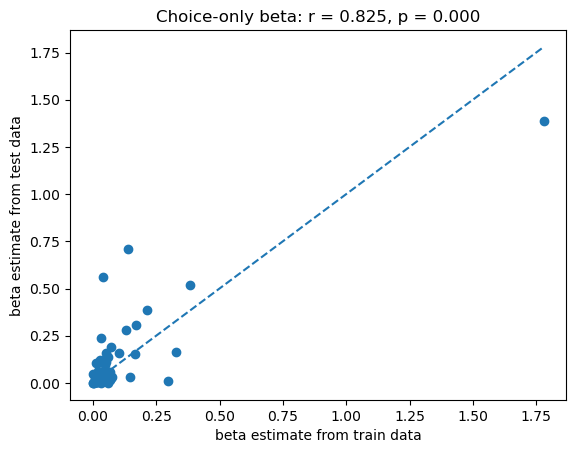

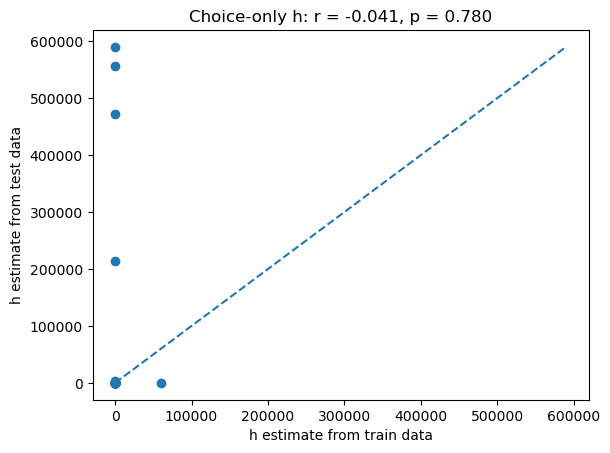

,model,parameter,r,p
0,choice-only,beta,0.824780,3.205039e-13
1,choice-only,h,-0.040901,7.802182e-01


In [21]:
co_parameters = ["beta", "h"]

co_corr_results = []

for param in co_parameters: 
    train_col = f"co_train_{param}" 
    test_col = f"co_test_{param}"

    r, p = compute_train_test_correlation(df_choice_only, train_col, test_col)

    plt.figure()
    plt.scatter(df_choice_only[train_col], df_choice_only[test_col])

    min_val = min(df_choice_only[train_col].min(), df_choice_only[test_col].min())
    max_val = max(df_choice_only[train_col].max(), df_choice_only[test_col].max())

    plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

    plt.xlabel(f"{param} estimate from train data") 
    plt.ylabel(f"{param} estimate from test data") 
    plt.title(f"Choice-only {param}: r = {r:.3f}, p = {p:.3f}") 
    plt.show()
    
    co_corr_results.append({
        "model": "choice-only", 
        "parameter": param, 
        "r": r,
        "p": p 
    })

df_co_corr = pd.DataFrame(co_corr_results) 
df_co_corr

# Parameter recovery for the choice-only model

In [22]:
# Function to generate choices:
def simulate_choice_data(data, beta_true, h_true, random_state=None):

    rng = np.random.default_rng(random_state)

    r_cert, r_uncert, p, _, rt = prepare_data(data)
    
    v_cert, v_uncert = compute_subjective_values( 
        r_cert=r_cert,
        r_uncert=r_uncert, 
        p=p,
        h=h_true
    )
    
    pi = compute_choice_probability( 
        v_cert=v_cert,
        v_uncert=v_uncert,
        beta=beta_true
    )

    # Generate choices
    y_sim = rng.binomial(
        n=1,
        p=pi
    )

    return r_cert, r_uncert, p, y_sim, rt

In [23]:
def make_simulated_matrix(orig_data, beta_true, h_true, random_state=None):

    # Copy original data
    data = np.asarray(orig_data, dtype=float).copy()

    valid = (data[:, 3] != 0) & np.isfinite(data[:, 6]) & (data[:, 6] > 0) 

    _, _, _, y_sim, _ = simulate_choice_data(
        orig_data,
        beta_true=beta_true,
        h_true=h_true,
        random_state=random_state
    )

    # Convert back to original coding:
    # 1 = certain
    # 2 = uncertain
    data[valid, 3] = np.where(y_sim == 1, 1, 2)

    return data

In [24]:
def parameter_recovery(data, beta_true, h_true, n_simulations=10, participant=None):

    recovery_results = []

    for sim in range(n_simulations):

        simulated_data = make_simulated_matrix(
            data,
            beta_true=beta_true,
            h_true=h_true,
            random_state=sim
        )

        result, _ = fit_choice_only(simulated_data)

        if result is None or not result.success:
            continue

        beta_recovered = result.x[0]
        h_recovered = result.x[1]

        recovery_results.append({
            "participant": participant,
            "simulation": sim,
            "beta_true": beta_true,
            "h_true": h_true,
            "beta_recovered": beta_recovered,
            "h_recovered": h_recovered,
            "nll": result.fun,
            "success": result.success
        })

    return pd.DataFrame(recovery_results)

In [25]:
co_beta_values = [0.1, 1, 10] 
co_h_values = [0.1, 1, 10]

co_all_recovery = []

# Take 10 participants for recovery
recovery_files = mat_files[:10]

for file in recovery_files:

    print(f"Running recovery for {file.stem}...")

    mat = sio.loadmat(file)
    data_train = mat["data_train"]

    co_participant_results = []

    for beta_true in co_beta_values:
        for h_true in co_h_values:

            recovery = parameter_recovery(
                data=data_train,
                beta_true=beta_true,
                h_true=h_true,
                n_simulations=10,
                participant=file.stem
            )

            co_participant_results.append(recovery)

    co_participant_results = pd.concat(
        co_participant_results,
        ignore_index=True
    )

    co_all_recovery.append(co_participant_results)

df_co_recovery = pd.concat(
    co_all_recovery,
    ignore_index=True
)

print(df_co_recovery.shape)
print(df_co_recovery.head())


Running recovery for 2rrjzhgj9...
Running recovery for 3lmzwis6r...
Running recovery for 4f8msviwg...
Running recovery for 52b64k0rp...
Running recovery for 5wlmihb4c...
Running recovery for 6owg3par9...
Running recovery for 8py7pm5i0...
Running recovery for 95vrrzevd...
Running recovery for bh348lli7...
Running recovery for c0ry57ax9...
(900, 8)
  participant  simulation  beta_true  h_true  beta_recovered  h_recovered  \
0   2rrjzhgj9           0        0.1     0.1        0.068707     0.065091   
1   2rrjzhgj9           1        0.1     0.1        0.067207     0.131397   
2   2rrjzhgj9           2        0.1     0.1        0.116848     0.079550   
3   2rrjzhgj9           3        0.1     0.1        0.106885     0.068586   
4   2rrjzhgj9           4        0.1     0.1        0.072839     0.076521   

         nll  success  
0  89.172908     True  
1  92.227603     True  
2  80.733427     True  
3  81.692048     True  
4  88.718453     True  


In [26]:
beta_r, beta_p = pearsonr(
    df_co_recovery["beta_true"],
    df_co_recovery["beta_recovered"]
)

beta_rmse = np.sqrt(
    np.mean(
        (
            df_co_recovery["beta_recovered"]
            - df_co_recovery["beta_true"]
        ) ** 2
    )
)

beta_bias = np.mean(
    df_co_recovery["beta_recovered"]
    - df_co_recovery["beta_true"]
)

h_r, h_p = pearsonr(
    df_co_recovery["h_true"],
    df_co_recovery["h_recovered"]
)

h_rmse = np.sqrt(
    np.mean(
        (
            df_co_recovery["h_recovered"]
            - df_co_recovery["h_true"]
        ) ** 2
    )
)

h_bias = np.mean(
    df_co_recovery["h_recovered"]
    - df_co_recovery["h_true"]
)

print("Parameter recovery")
print("------------------")

print(f"beta:")
print(f"  correlation = {beta_r:.3f}")
print(f"  RMSE = {beta_rmse:.3f}")
print(f"  bias = {beta_bias:.3f}")

print(f"\nh:")
print(f"  correlation = {h_r:.3f}")
print(f"  RMSE = {h_rmse:.3f}")
print(f"  bias = {h_bias:.3f}")

Parameter recovery
------------------
beta:
  correlation = 0.370
  RMSE = 100.261
  bias = 22.895

h:
  correlation = 0.991
  RMSE = 0.594
  bias = 0.033


Plots for parameter recovery

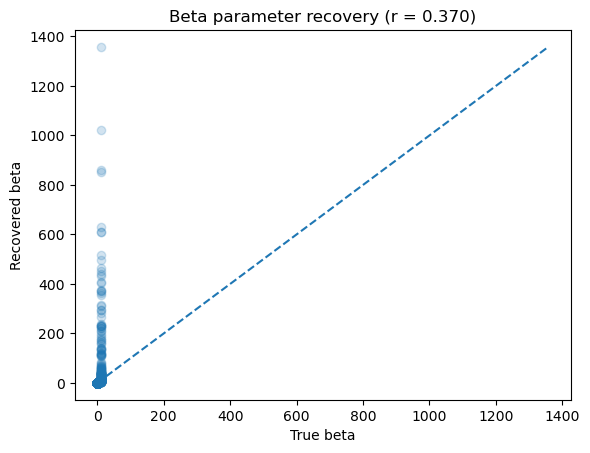

In [27]:
plt.figure()

plt.scatter(df_co_recovery["beta_true"], df_co_recovery["beta_recovered"], alpha=0.2)

min_val = min(df_co_recovery["beta_true"].min(), df_co_recovery["beta_recovered"].min())
max_val = max(df_co_recovery["beta_true"].max(), df_co_recovery["beta_recovered"].max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("True beta") 
plt.ylabel("Recovered beta") 
plt.title(f"Beta parameter recovery (r = {beta_r:.3f})") 
plt.show()

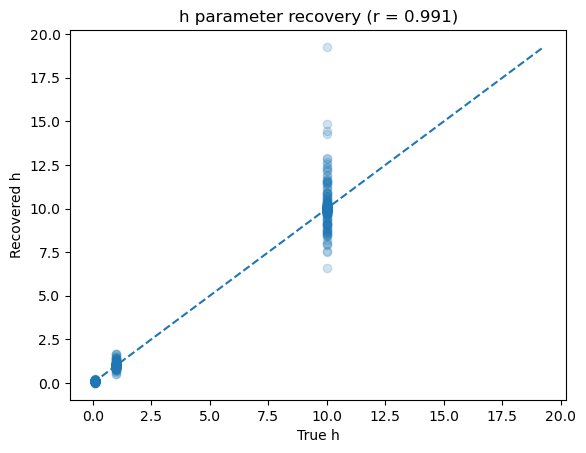

In [28]:
plt.figure()

plt.scatter(df_co_recovery["h_true"], df_co_recovery["h_recovered"], alpha=0.2)

min_val = min(df_co_recovery["h_true"].min(), df_co_recovery["h_recovered"].min())
max_val = max(df_co_recovery["h_true"].max(), df_co_recovery["h_recovered"].max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("True h") 
plt.ylabel("Recovered h") 
plt.title(f"h parameter recovery (r = {h_r:.3f})") 
plt.show()

# RT model 1: Absolute conflict

Combine choice model with absolute conflict.

In [ ]:
def nll_absolute_conflict(params, data): 

    beta, a, b, h, sigma, tau = params

    # Safety check
    if beta <= 0 or b <= 0 or h <= 0 or sigma <= 0: 
        return np.inf
    
    r_cert, r_uncert, p, y, rt = prepare_data(data)

    v_cert, v_uncert = compute_subjective_values(r_cert, r_uncert, p, h)

    pi = compute_choice_probability(v_cert, v_uncert, beta)

    eps = 1e-12
    pi = np.clip(pi, eps, 1 - eps)

    log_likelihood_choice = np.sum(
        y * np.log(pi) + (1 - y) * np.log(1 - pi)
    )

    # RT as shifted log normal
    rt_shifted = rt - tau

    if np.any(rt_shifted <= 0):
        return np.inf
    
    log_rt = np.log(rt_shifted)

    # Absolute conflict
    conflict = np.abs(v_uncert - v_cert)
    mu = a - b * conflict

    log_likelihood_rt = np.sum( 
        - log_rt
        - 0.5 * np.log(2 * np.pi * sigma ** 2)
        - ((log_rt - mu) ** 2) / (2 * sigma ** 2) 
    )

    total_log_likelihood = log_likelihood_choice + log_likelihood_rt 

    return -total_log_likelihood

# RT model 2: Squared conflict

Combine choice model with squared conflict.

In [ ]:
def nll_squared_conflict(params, data): 

    beta, a, b, h, sigma, tau = params

    # Safety check
    if beta <= 0 or b <= 0 or h <= 0 or sigma <= 0: 
        return np.inf
    
    r_cert, r_uncert, p, y, rt = prepare_data(data)

    v_cert, v_uncert = compute_subjective_values(r_cert, r_uncert, p, h)

    pi = compute_choice_probability(v_cert, v_uncert, beta)

    eps = 1e-12
    pi = np.clip(pi, eps, 1 - eps)

    log_likelihood_choice = np.sum(
        y * np.log(pi) + (1 - y) * np.log(1 - pi)
    )

    # RT as shifted log normal
    rt_shifted = rt - tau

    if np.any(rt_shifted <= 0):
        return np.inf
    
    log_rt = np.log(rt_shifted)

    # Squared conflict
    conflict = (v_uncert - v_cert) ** 2
    mu = a - b * conflict

    log_likelihood_rt = np.sum( 
        - log_rt
        - 0.5 * np.log(2 * np.pi * sigma ** 2)
        - ((log_rt - mu) ** 2) / (2 * sigma ** 2) 
    )

    total_log_likelihood = log_likelihood_choice + log_likelihood_rt 

    return -total_log_likelihood

# RT model 3: Exponential value-difference mapping

Combine choice model with exponential mapping.

In [ ]:
def nll_exponential(params, data): 

    beta, a, b, h, sigma, tau = params

    # Safety check
    if beta <= 0 or b <= 0 or h <= 0 or sigma <= 0: 
        return np.inf
    
    r_cert, r_uncert, p, y, rt = prepare_data(data)

    v_cert, v_uncert = compute_subjective_values(r_cert, r_uncert, p, h)

    pi = compute_choice_probability(v_cert, v_uncert, beta)

    eps = 1e-12
    pi = np.clip(pi, eps, 1 - eps)

    log_likelihood_choice = np.sum(
        y * np.log(pi) + (1 - y) * np.log(1 - pi)
    )

    # RT as shifted log normal
    rt_shifted = rt - tau

    if np.any(rt_shifted <= 0):
        return np.inf
    
    log_rt = np.log(rt_shifted)

    # Exponential mapping
    conflict = np.exp(-np.abs(v_uncert - v_cert))
    mu = a + b * conflict

    log_likelihood_rt = np.sum( 
        - log_rt
        - 0.5 * np.log(2 * np.pi * sigma ** 2)
        - ((log_rt - mu) ** 2) / (2 * sigma ** 2) 
    )

    total_log_likelihood = log_likelihood_choice + log_likelihood_rt 

    return -total_log_likelihood